# INEN + SCOE electricity demand calibration for Morocco (2022 baseline)

Two-stage calibration of industrial (INEN) and stationary combustion-other (SCOE) electricity demand against IEA Morocco total electricity production.

**Stage A** – Diagnose INEN electricity demand per subsector for the calibration year. Generates a table the user can review and optionally fill with overrides per subsector (consumpinit_* factor). No factor is applied by default.

**Stage B** – Compute the SCOE residual factor for the calibration year such that `INEN + SCOE + CCSQ + TRNS = IEA × (1 − transmission_loss)` (in PJ). Apply the factor to the six SCOE scalar columns and hold it flat through 2050 (avoids the 1.0-reset cliff).

Starts from `..._FROZEN_TECH_INDUSTRY.csv` (the frozen-AEEI BAU base built on 2026-05-21). Output: `..._FROZEN_TECH_INDUSTRY_inen_scoe_calibrated.csv`.

In [15]:
# ============================================================
# Parameters
# ============================================================

# Base CSV (frozen-AEEI industrial base built on 2026-05-21)
BASE_INPUT_CSV = "../../input_data/sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement_FROZEN_TECH_INDUSTRY.csv"

# Output CSV (after INEN diagnostic + SCOE residual)
OUT_INPUT_CSV  = "../../input_data/sisepuede_raw_input_morocco.csv"

# IEA historical electricity production (GWh) - https://www.iea.org/countries/morocco/electricity
IEA_CSV = "../../input_data/reference/iea_morocco_electricity_production.csv"

# Calibration year (single year as per user decision 2026-05-21)
CALIB_YEAR = 2022

# Base year (t=0) of the SISEPUEDE input
BASE_YEAR = 2015

# Terminal year of the input CSV (used to extend the post-calibration scalar)
TERMINAL_YEAR = 2050

# Post-calibration strategy (extends scalar from CALIB_YEAR+1 to TERMINAL_YEAR):
#   "hold"        - hold the CALIB_YEAR scalar flat through TERMINAL_YEAR
#   "linear_to_1" - linearly fade to 1.0 over POST_CALIB_FADE_YEARS years
#   "reset"       - leave original value (=1.0); produces a visible step
POST_CALIB_STRATEGY = "hold"
POST_CALIB_FADE_YEARS = 10

# Transmission loss override (None => read per-year from CSV column)
TRANSMISSION_LOSS_OVERRIDE = None

# Validation tolerance for total electricity
REL_TOLERANCE = 0.01

# SCOE factor clamp
F_SCOE_MIN = 0.1
F_SCOE_MAX = 10.0

REGION = "morocco"

# ============================================================
# Stage A overrides (per-subsector INEN electricity demand targets)
# ============================================================
# Map: subsector name -> target electricity demand in PJ for CALIB_YEAR.
# Leave empty to skip Stage A modifications (diagnostic only).
# When populated, the notebook computes factor_c = target_c / baseline_c and
# multiplies the corresponding consumpinit_inen_energy_*_<subsector> column(s).
#
# Example:
#   INEN_OVERRIDES = {
#       "cement":    3.5,   # PJ electricity demand in 2022
#       "chemicals": 4.2,
#   }
INEN_OVERRIDES = {}


In [16]:
import os, sys, pathlib, warnings, logging
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

HERE = pathlib.Path(os.getcwd())
sys.path.insert(0, str(HERE.parent))
from utils.logger_utils import setup_clean_logger, mute_external_loggers
logger = setup_clean_logger("recalib_inen_scoe", logging.INFO)
mute_external_loggers(["sisepuede"])

# 1 PJ = 1e15 J;  1 GWh = 3.6e12 J  ->  1 PJ = 1000/3.6 GWh
PJ_TO_GWH = 1000.0 / 3.6
GWH_TO_PJ = 3.6 / 1000.0


## 1. Helpers (energy model runner + per-subsector splitter)

In [17]:
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
from ssp_transformations_handler.GeneralUtils import GeneralUtils

_EXAMPLES = sxl.SISEPUEDEExamples()


def run_energy_only(csv_path: str, y0: int = BASE_YEAR, y1: int = 2050) -> pd.DataFrame:
    """Run only EnergyConsumption (INEN+SCOE+CCSQ+TRNS), no NemoMod."""
    df_raw = pd.read_csv(csv_path)
    fs = sfs.SISEPUEDEFileStructure(initialize_directories=False)
    key_tp = fs.model_attributes.dim_time_period
    key_year = fs.model_attributes.field_dim_year
    years = np.arange(y0, y1 + 1).astype(int)
    att_tp = att.AttributeTable(
        pd.DataFrame({key_tp: range(len(years)), key_year: years}), key_tp,
    )
    fs.model_attributes.update_dimensional_attribute_table(att_tp)
    matt = fs.model_attributes
    models = sm.SISEPUEDEModels(
        matt, allow_electricity_run=False,
        fp_julia=fs.dir_jl, fp_nemomod_reference_files=fs.dir_ref_nemo,
        initialize_julia=False,
    )
    df_ex = _EXAMPLES("input_data_frame")
    df = GeneralUtils().add_missing_cols(df_ex, df_raw.copy())
    df["region"] = REGION
    df = df[df["year"] <= y1]
    df_out = models.project(df, include_electricity_in_energy=False)
    df_out["year"] = df_out["time_period"].apply(lambda t: y0 + int(t))
    return df_out


def split_elec_by_sector(df_out: pd.DataFrame) -> pd.DataFrame:
    """Per-year PJ split: inen / scoe / ccsq / trns / total."""
    rows = []
    trns_cols = [c for c in df_out.columns
                 if c.startswith("energy_consumption_electricity_trns_")
                 and not c.endswith("_total")]
    for _, row in df_out.iterrows():
        inen = float(row.get("energy_consumption_electricity_inen_total", 0.0))
        scoe = float(row.get("energy_consumption_electricity_scoe_total", 0.0))
        ccsq = float(row.get("energy_consumption_electricity_ccsq_total", 0.0))
        trns = float(sum(row[c] for c in trns_cols))
        rows.append({"year": int(row["year"]), "inen": inen, "scoe": scoe,
                     "ccsq": ccsq, "trns": trns,
                     "total": inen + scoe + ccsq + trns})
    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def inen_elec_by_subsector(df_out: pd.DataFrame, df_in: pd.DataFrame, year: int) -> pd.DataFrame:
    """For CALIB_YEAR, decompose INEN electricity demand by industrial subsector.
    
    Uses: energy_demand_inen_<subsector> (total fuel PJ) × frac_inen_energy_<subsector>_electricity.
    Returns DataFrame with columns: subsector, total_pj, elec_frac, elec_pj, pct_of_inen_elec.
    """
    row_out = df_out[df_out["year"] == year].iloc[0]
    row_in  = df_in[df_in["year"] == year].iloc[0] if "year" in df_in.columns \
              else df_in[df_in["time_period"] == year - BASE_YEAR].iloc[0]
    
    rows = []
    for col in df_out.columns:
        if not col.startswith("energy_demand_inen_"):
            continue
        sub = col[len("energy_demand_inen_"):]
        if sub.endswith("_total"):
            continue
        frac_col = f"frac_inen_energy_{sub}_electricity"
        if frac_col not in df_in.columns:
            continue
        total_pj = float(row_out[col])
        elec_frac = float(row_in[frac_col])
        elec_pj  = total_pj * elec_frac
        rows.append({"subsector": sub, "total_pj": total_pj,
                     "elec_frac": elec_frac, "elec_pj": elec_pj})
    df = pd.DataFrame(rows).sort_values("elec_pj", ascending=False).reset_index(drop=True)
    if df["elec_pj"].sum() > 0:
        df["pct_of_inen_elec"] = 100 * df["elec_pj"] / df["elec_pj"].sum()
    else:
        df["pct_of_inen_elec"] = 0.0
    return df


## 2. Stage A — Diagnose INEN electricity demand by subsector (CALIB_YEAR)

Runs the energy model on the frozen-tech base, then breaks down INEN electricity demand by industrial subsector. Use this table to identify which subsectors look off vs your prior knowledge (e.g. cement should be N PJ, chemicals N′ PJ). Fill `INEN_OVERRIDES` in the parameters cell and re-run to apply factor corrections.

In [18]:
# Load IEA reference + run base
iea = pd.read_csv(IEA_CSV)
iea.columns = [c.strip() for c in iea.columns]
value_col = [c for c in iea.columns if "electricity" in c.lower()][0]
iea = iea.rename(columns={value_col: "iea_gwh"})[["Year", "iea_gwh"]].rename(columns={"Year": "year"})
iea_calib_gwh = float(iea[iea["year"] == CALIB_YEAR]["iea_gwh"].iloc[0])
print(f"IEA {CALIB_YEAR} total electricity production: {iea_calib_gwh:,.0f} GWh = {iea_calib_gwh * GWH_TO_PJ:.2f} PJ")

df_base = pd.read_csv(BASE_INPUT_CSV)
df_base["year"] = df_base["time_period"] + BASE_YEAR

print(f"\nRunning EnergyConsumption only on base CSV...")
df_out_base = run_energy_only(BASE_INPUT_CSV)

# Per-sector breakdown at CALIB_YEAR
elec_base = split_elec_by_sector(df_out_base)
baseline_row = elec_base[elec_base["year"] == CALIB_YEAR].iloc[0]
print(f"\nBaseline electricity end-use at {CALIB_YEAR} (PJ):")
print(f"  INEN:  {baseline_row['inen']:.2f}")
print(f"  SCOE:  {baseline_row['scoe']:.2f}")
print(f"  CCSQ:  {baseline_row['ccsq']:.2f}")
print(f"  TRNS:  {baseline_row['trns']:.2f}")
print(f"  TOTAL: {baseline_row['total']:.2f} PJ = {baseline_row['total'] * PJ_TO_GWH:,.0f} GWh")
print(f"  IEA target (after loss): see Stage B")


IEA 2022 total electricity production: 42,722 GWh = 153.80 PJ

Running EnergyConsumption only on base CSV...

Baseline electricity end-use at 2022 (PJ):
  INEN:  35.99
  SCOE:  93.70
  CCSQ:  0.00
  TRNS:  0.83
  TOTAL: 130.52 PJ = 36,255 GWh
  IEA target (after loss): see Stage B


In [19]:
# Stage A diagnostic: INEN electricity demand per subsector
inen_table = inen_elec_by_subsector(df_out_base, df_base, CALIB_YEAR)

# Annotate with driver type for context
def driver_type(sub):
    if sub == "agriculture_and_livestock":
        return "total_pj (exogenous)"
    if sub == "other_product_manufacturing":
        return "tj_per_mmm_gdp"
    return "tj_per_tonne_production"

inen_table["driver"] = inen_table["subsector"].apply(driver_type)
inen_table["override_target_pj"] = inen_table["subsector"].map(INEN_OVERRIDES).astype(float)

print(f"=" * 80)
print(f"INEN electricity demand by subsector at {CALIB_YEAR} (baseline, before any override)")
print(f"=" * 80)
cols_show = ["subsector", "total_pj", "elec_frac", "elec_pj", "pct_of_inen_elec", "driver", "override_target_pj"]
print(inen_table[cols_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nTotal INEN electricity: {inen_table['elec_pj'].sum():.2f} PJ ({baseline_row['inen']:.2f} from split)")

# Apply Stage A overrides if any
if INEN_OVERRIDES:
    print(f"\nApplying {len(INEN_OVERRIDES)} Stage A overrides...")
    df_a = df_base.copy()
    for sub, target_pj in INEN_OVERRIDES.items():
        baseline_pj = float(inen_table.loc[inen_table["subsector"] == sub, "elec_pj"].iloc[0])
        if baseline_pj <= 0:
            print(f"  WARNING: {sub} baseline = 0, skipping")
            continue
        factor = target_pj / baseline_pj
        if sub == "agriculture_and_livestock":
            cols = [f"consumpinit_inen_energy_total_pj_agriculture_and_livestock"]
        elif sub == "other_product_manufacturing":
            cols = [f"consumpinit_inen_energy_tj_per_mmm_gdp_other_product_manufacturing"]
        else:
            cols = [f"consumpinit_inen_energy_tj_per_tonne_production_{sub}"]
            recycled = f"consumpinit_inen_energy_tj_per_tonne_production_recycled_{sub}"
            if recycled in df_a.columns:
                cols.append(recycled)
        present = [c for c in cols if c in df_a.columns]
        for c in present:
            df_a[c] = df_a[c] * factor
        print(f"  {sub}: baseline={baseline_pj:.3f} PJ -> target={target_pj:.3f} PJ (factor={factor:.4f}, cols={present})")
    
    # Save intermediate Stage A CSV (will be overwritten in Stage B)
    STAGE_A_CSV = OUT_INPUT_CSV.replace(".csv", "_stageA.csv")
    df_a.to_csv(STAGE_A_CSV, index=False)
    print(f"  Wrote Stage A intermediate: {STAGE_A_CSV}")
    STAGE_B_INPUT = STAGE_A_CSV
else:
    print(f"\nINEN_OVERRIDES is empty -> Stage A is diagnostic-only. Stage B will use {BASE_INPUT_CSV}")
    STAGE_B_INPUT = BASE_INPUT_CSV


INEN electricity demand by subsector at 2022 (baseline, before any override)
                  subsector  total_pj  elec_frac  elec_pj  pct_of_inen_elec                  driver  override_target_pj
                      paper   44.6673     0.5843  26.0991           30.2156 tj_per_tonne_production                 NaN
                  chemicals   40.2101     0.5843  23.4948           27.2005 tj_per_tonne_production                 NaN
                       wood   17.3371     0.5843  10.1301           11.7278 tj_per_tonne_production                 NaN
                     cement   33.3960     0.2941   9.8224           11.3716 tj_per_tonne_production                 NaN
                     metals   14.9850     0.5843   8.7558           10.1368 tj_per_tonne_production                 NaN
                    plastic    8.0685     0.5843   4.7144            5.4580 tj_per_tonne_production                 NaN
         rubber_and_leather    2.4262     0.5843   1.4176            1.6412 tj_per_

## 3. Stage B — SCOE residual calibration to IEA (CALIB_YEAR with hold to 2050)

Computes the SCOE scalar f such that `f × current_SCOE + INEN + CCSQ + TRNS = IEA × (1 − loss)` at `CALIB_YEAR`. Writes f to the 6 SCOE scalar columns at CALIB_YEAR and applies the chosen post-window strategy (default: hold).

In [20]:
SCOE_SCALAR_COLS = [
    "scalar_scoe_appliance_energy_demand_commercial_municipal",
    "scalar_scoe_appliance_energy_demand_other_se",
    "scalar_scoe_appliance_energy_demand_residential",
    "scalar_scoe_heat_energy_demand_commercial_municipal",
    "scalar_scoe_heat_energy_demand_other_se",
    "scalar_scoe_heat_energy_demand_residential",
]

# Re-run energy model if Stage A applied overrides, else reuse df_out_base
if INEN_OVERRIDES:
    print(f"Re-running EnergyConsumption after Stage A overrides...")
    df_out_a = run_energy_only(STAGE_B_INPUT)
    elec_a = split_elec_by_sector(df_out_a)
else:
    elec_a = elec_base.copy()

baseline_a = elec_a[elec_a["year"] == CALIB_YEAR].iloc[0]

df_in = pd.read_csv(STAGE_B_INPUT)
missing = [c for c in SCOE_SCALAR_COLS if c not in df_in.columns]
assert not missing, f"Missing SCOE scalar columns: {missing}"

# Transmission loss for CALIB_YEAR
if TRANSMISSION_LOSS_OVERRIDE is not None:
    loss = float(TRANSMISSION_LOSS_OVERRIDE)
else:
    loss_col = "frac_enfu_transmission_loss_fuel_electricity"
    assert loss_col in df_in.columns, f"Column {loss_col} missing and no override provided"
    df_in["year"] = df_in["time_period"] + BASE_YEAR
    loss = float(df_in.loc[df_in["year"] == CALIB_YEAR, loss_col].iloc[0])

target_enduse_pj = iea_calib_gwh * (1.0 - loss) * GWH_TO_PJ
fixed_pj   = float(baseline_a["inen"] + baseline_a["ccsq"] + baseline_a["trns"])
need_scoe  = target_enduse_pj - fixed_pj
current_scoe = float(baseline_a["scoe"])
if current_scoe <= 0:
    f_scoe = 1.0
    print(f"WARNING: current SCOE = 0, factor set to 1.0")
else:
    f_scoe = float(np.clip(need_scoe / current_scoe, F_SCOE_MIN, F_SCOE_MAX))

print(f"=" * 80)
print(f"Stage B — SCOE residual for {CALIB_YEAR}")
print(f"=" * 80)
print(f"  IEA production:              {iea_calib_gwh:,.0f} GWh")
print(f"  Transmission loss:           {loss:.4f}")
print(f"  Target end-use:              {target_enduse_pj:.3f} PJ = {target_enduse_pj * PJ_TO_GWH:,.0f} GWh")
print(f"  Fixed (INEN+CCSQ+TRNS):      {fixed_pj:.3f} PJ")
print(f"    INEN:                      {baseline_a['inen']:.3f} PJ")
print(f"    CCSQ:                      {baseline_a['ccsq']:.3f} PJ")
print(f"    TRNS:                      {baseline_a['trns']:.3f} PJ")
print(f"  Required SCOE:               {need_scoe:.3f} PJ")
print(f"  Current SCOE:                {current_scoe:.3f} PJ")
print(f"  SCOE scalar factor:          {f_scoe:.4f}")

# Build year-by-year correction multiplier:
#   y <  CALIB_YEAR  -> 1.0 (preserve historical calibration in base CSV)
#   y == CALIB_YEAR  -> f_scoe (multiplicative correction)
#   y >  CALIB_YEAR  -> per POST_CALIB_STRATEGY
all_years = sorted(df_in["year"].astype(int).unique())
plan = []
for y in all_years:
    if y < CALIB_YEAR:
        plan.append({"year": y, "correction": 1.0})
    elif y == CALIB_YEAR:
        plan.append({"year": y, "correction": f_scoe})
    else:
        if POST_CALIB_STRATEGY == "hold":
            c_post = f_scoe
        elif POST_CALIB_STRATEGY == "linear_to_1":
            step = y - CALIB_YEAR
            if step <= POST_CALIB_FADE_YEARS:
                c_post = f_scoe + (1.0 - f_scoe) * (step / POST_CALIB_FADE_YEARS)
            else:
                c_post = 1.0
        elif POST_CALIB_STRATEGY == "reset":
            c_post = 1.0
        else:
            raise ValueError(f"Unknown POST_CALIB_STRATEGY={POST_CALIB_STRATEGY!r}")
        plan.append({"year": y, "correction": c_post})
plan_df = pd.DataFrame(plan)

# Compute resulting absolute scalars (existing * correction) for diagnostic
existing_at_calib = float(df_in.loc[df_in["year"]==CALIB_YEAR, SCOE_SCALAR_COLS[0]].iloc[0])
print(f"\nExisting scalar at {CALIB_YEAR} (in base CSV): {existing_at_calib:.4f}")
print(f"Correction multiplier: {f_scoe:.4f}")
print(f"New absolute scalar at {CALIB_YEAR}: {existing_at_calib * f_scoe:.4f}")

print(f"\nCorrection plan (showing 2015, {CALIB_YEAR}, {CALIB_YEAR+1}, 2030, 2050):")
show_years = [2015, CALIB_YEAR, CALIB_YEAR+1, 2030, 2050]
print(plan_df[plan_df["year"].isin(show_years)].to_string(index=False))

# Apply correction multiplicatively to df_in (preserves the existing year-by-year shape)
year_to_tp = dict(zip(df_in["year"], df_in["time_period"]))
for _, r in plan_df.iterrows():
    y = int(r["year"])
    if y not in year_to_tp:
        continue
    correction = float(r["correction"])
    if correction == 1.0:
        continue  # no-op, preserve existing
    mask = df_in["time_period"] == year_to_tp[y]
    for c in SCOE_SCALAR_COLS:
        df_in.loc[mask, c] = df_in.loc[mask, c] * correction

os.makedirs(os.path.dirname(OUT_INPUT_CSV), exist_ok=True)
df_in.to_csv(OUT_INPUT_CSV, index=False)
print(f"\nWrote calibrated input to: {OUT_INPUT_CSV}")


Stage B — SCOE residual for 2022
  IEA production:              42,722 GWh
  Transmission loss:           0.1651
  Target end-use:              128.401 PJ = 35,667 GWh
  Fixed (INEN+CCSQ+TRNS):      36.819 PJ
    INEN:                      35.987 PJ
    CCSQ:                      0.000 PJ
    TRNS:                      0.832 PJ
  Required SCOE:               91.582 PJ
  Current SCOE:                93.698 PJ
  SCOE scalar factor:          0.9774

Existing scalar at 2022 (in base CSV): 1.6071
Correction multiplier: 0.9774
New absolute scalar at 2022: 1.5708

Correction plan (showing 2015, 2022, 2023, 2030, 2050):
 year  correction
 2015     1.00000
 2022     0.97742
 2023     0.97742
 2030     0.97742
 2050     0.97742

Wrote calibrated input to: ../../input_data/sisepuede_raw_input_morocco.csv


## 4. Validation

Re-runs the energy model on the output CSV and confirms the total electricity end-use matches IEA at CALIB_YEAR within REL_TOLERANCE.

In [21]:
df_out_new = run_energy_only(OUT_INPUT_CSV)
elec_new = split_elec_by_sector(df_out_new)
row_new = elec_new[elec_new["year"] == CALIB_YEAR].iloc[0]

iea_pj = iea_calib_gwh * GWH_TO_PJ
iea_end_pj = iea_calib_gwh * (1.0 - loss) * GWH_TO_PJ

print(f"=" * 80)
print(f"Validation at {CALIB_YEAR}")
print(f"=" * 80)
print(f"  Component breakdown (PJ):")
print(f"    INEN:  {row_new['inen']:.3f}")
print(f"    SCOE:  {row_new['scoe']:.3f}")
print(f"    CCSQ:  {row_new['ccsq']:.3f}")
print(f"    TRNS:  {row_new['trns']:.3f}")
print(f"    TOTAL: {row_new['total']:.3f} PJ end-use")
print(f"\n  Target (IEA × (1-loss)): {iea_end_pj:.3f} PJ end-use")
print(f"  Gap:                    {row_new['total'] - iea_end_pj:+.3f} PJ")
print(f"  Ratio (model/target):   {row_new['total'] / iea_end_pj:.5f}")

gap_frac = abs(row_new["total"] - iea_end_pj) / iea_end_pj
if gap_frac <= REL_TOLERANCE:
    print(f"\n  PASS: within {REL_TOLERANCE*100:.1f}% tolerance ({gap_frac*100:.3f}%)")
else:
    print(f"\n  FAIL: {gap_frac*100:.3f}% exceeds {REL_TOLERANCE*100:.1f}% tolerance")
    print(f"  Likely cause: f_scoe clamped to F_SCOE_MIN/MAX, or INEN/CCSQ/TRNS demand exceeds IEA target")

# INEN per-subsector after Stage A (if applied) for the record
if INEN_OVERRIDES:
    inen_table_new = inen_elec_by_subsector(df_out_new, pd.read_csv(OUT_INPUT_CSV).assign(year=lambda x: x["time_period"]+BASE_YEAR), CALIB_YEAR)
    print(f"\nINEN electricity by subsector at {CALIB_YEAR} (post-Stage-A):")
    print(inen_table_new[["subsector","elec_pj","pct_of_inen_elec"]].to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Validation at 2022
  Component breakdown (PJ):
    INEN:  35.987
    SCOE:  91.582
    CCSQ:  0.000
    TRNS:  0.832
    TOTAL: 128.401 PJ end-use

  Target (IEA × (1-loss)): 128.401 PJ end-use
  Gap:                    +0.000 PJ
  Ratio (model/target):   1.00000

  PASS: within 1.0% tolerance (0.000%)


## 5. Diagnostic plot (before/after)

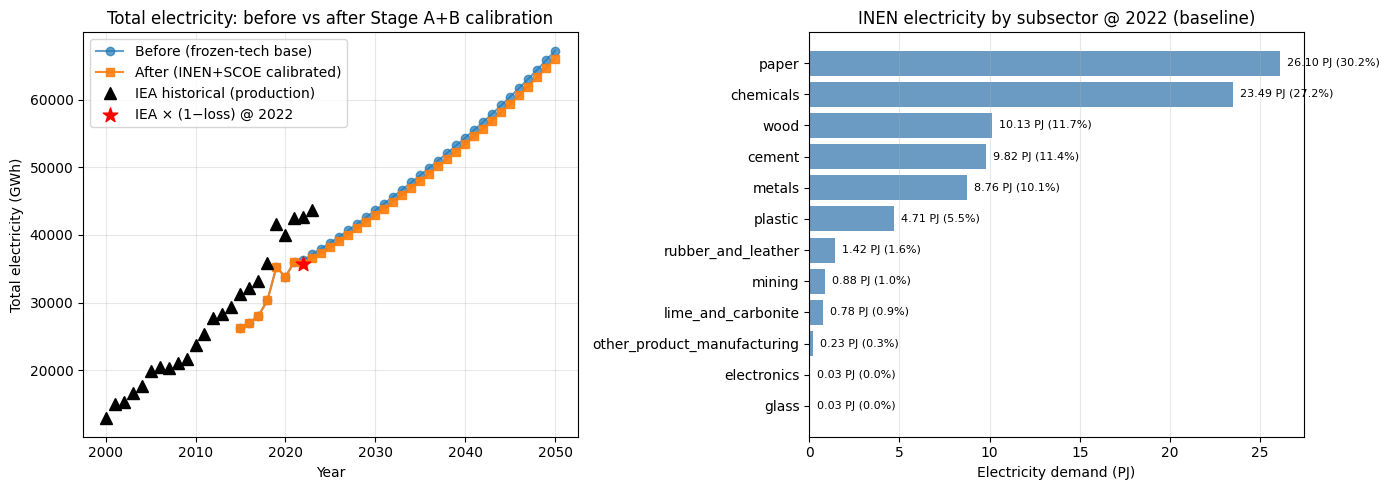

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total electricity over time, before vs after vs IEA
ax = axes[0]
ax.plot(elec_base["year"], elec_base["total"] * PJ_TO_GWH, "o-", label="Before (frozen-tech base)", alpha=0.7)
ax.plot(elec_new["year"],  elec_new["total"]  * PJ_TO_GWH, "s-", label="After (INEN+SCOE calibrated)", alpha=0.9)
iea_years = iea["year"].values
iea_vals  = iea["iea_gwh"].values
ax.plot(iea_years, iea_vals, "k^", markersize=8, label="IEA historical (production)")
# loss-adjusted IEA target (end-use) for the calibration year
ax.scatter([CALIB_YEAR], [iea_end_pj * PJ_TO_GWH], s=120, marker="*", c="red", label=f"IEA × (1−loss) @ {CALIB_YEAR}", zorder=10)
ax.set_xlabel("Year")
ax.set_ylabel("Total electricity (GWh)")
ax.set_title(f"Total electricity: before vs after Stage A+B calibration")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# Right: INEN per-subsector at CALIB_YEAR
ax = axes[1]
tbl = inen_table[inen_table["elec_pj"] > 0.001].copy()
y_pos = np.arange(len(tbl))
ax.barh(y_pos, tbl["elec_pj"], color="steelblue", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(tbl["subsector"])
ax.invert_yaxis()
ax.set_xlabel("Electricity demand (PJ)")
ax.set_title(f"INEN electricity by subsector @ {CALIB_YEAR} (baseline)")
ax.grid(True, alpha=0.3, axis="x")
for i, (pj, pct) in enumerate(zip(tbl["elec_pj"], tbl["pct_of_inen_elec"])):
    ax.text(pj, i, f"  {pj:.2f} PJ ({pct:.1f}%)", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## Notes

- **Diagnostic-only Stage A**: The notebook does NOT modify INEN by default. To apply per-subsector   overrides, fill `INEN_OVERRIDES` in the parameters cell with `{subsector_name: target_PJ}` pairs   and re-run.
- **Subsector targets data sources** (for filling INEN_OVERRIDES later):
  - Cement: SNBC fr p.157 (specific consumption + Lafarge/Holcim production)
  - Phosphates/Chemicals: OCP annual reports + ANRE balances
  - Metals: Aluminium du Maroc + Sonasid
  - General: HCP Morocco industrial statistics, MEME energy balance
- **Hold strategy beyond 2022**: The SCOE scalar is held flat from 2023 through 2050. If the   SISEPUEDE 2023+ projections start matching reality without the calibration adjustment, switch   POST_CALIB_STRATEGY to `linear_to_1` to fade the correction out.
- **Frozen-tech base**: This input keeps `efficfactor_*` constant at the 2018 value. Re-runs will   reflect 0% AEEI in BAU and the LEDS −17% milestone (Section 2 of `industry_targets_to_ssp_mapping.md`).